# Treatment Effect & Genotype Modulation Analysis: PBS vs Lecanemab

This notebook quantifies Aβ plaque burden, size, and distribution comparing Lecanemab vs PBS treatment groups, and evaluates how ApoE genotype (ApoE3 vs ApoE4) modulates the treatment effect.

## Outline
1. Setup & data loading  
2. Subject-level metrics (count, size, volume)  
3. Descriptive statistics & boxplots  
4. Violin plots of plaque-size distributions  
5. Two-way ANOVA (treatment × genotype) for each metric  
6. Interaction plots  
7. Post-hoc pairwise comparisons (Tukey HSD)  
8. Genotype-stratified analysis  
9. Summary of findings  

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings("ignore", category=FutureWarning)

# ── aesthetics ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
TREAT_ORDER   = ["PBS", "Lecanemab"]
TREAT_PALETTE = {"PBS": "#4C72B0", "Lecanemab": "#DD8452"}
GENO_ORDER    = ["ApoE3", "ApoE4"]
GENO_PALETTE  = {"ApoE3": "#55A868", "ApoE4": "#C44E52"}

## 1  Setup & data loading

In [2]:
# ── load & lightweight pre-processing ────────────────────────────────────────
VOL_THRESH_ML = 1e-4   # remove implausibly large plaques (same as scratch_analysis)

df_raw = pd.read_parquet("data.parquet")

df = df_raw.loc[df_raw["plaque_vol_ml"] <= VOL_THRESH_ML].copy()
df["treatment"] = pd.Categorical(df["treatment"], categories=TREAT_ORDER, ordered=True)
df["genotype"]  = pd.Categorical(df["genotype"],  categories=GENO_ORDER,  ordered=True)

print(f"Plaque instances after size filter: {len(df):,}  (removed {len(df_raw)-len(df):,})")
print()
print(df.groupby(["treatment", "genotype"])["subject"].nunique().rename("n_subjects").reset_index())

Plaque instances after size filter: 1,157,491  (removed 81,933)

   treatment genotype  n_subjects
0        PBS    ApoE3           3
1        PBS    ApoE4           5
2  Lecanemab    ApoE3           3
3  Lecanemab    ApoE4           5


## 2  Subject-level metrics

In [3]:
def compute_subject_metrics(plaque_df):
    """Aggregate plaque-level data to one row per subject."""
    grp = plaque_df.groupby(["subject", "treatment", "genotype", "sex"], observed=True)

    metrics = grp.agg(
        plaque_count     = ("nvoxels",       "size"),
        total_vol_ml     = ("plaque_vol_ml",  "sum"),
        mean_vol_ml      = ("plaque_vol_ml",  "mean"),
        median_vol_ml    = ("plaque_vol_ml",  "median"),
        mean_diam_um     = ("equiv_diam_um",  "mean"),
        median_diam_um   = ("equiv_diam_um",  "median"),
        total_vol_um3    = ("plaque_vol_um3", "sum"),
    ).reset_index()

    # log-transform heavily skewed outcomes (used for modelling)
    for col in ["plaque_count", "total_vol_ml", "mean_vol_ml", "median_vol_ml",
                "mean_diam_um", "median_diam_um", "total_vol_um3"]:
        metrics[f"log_{col}"] = np.log(metrics[col])

    return metrics


subj = compute_subject_metrics(df)
print(f"Subject-level table: {subj.shape}")
subj.head()

Subject-level table: (16, 18)


,subject,treatment,genotype,sex,plaque_count,total_vol_ml,mean_vol_ml,median_vol_ml,mean_diam_um,median_diam_um,total_vol_um3,log_plaque_count,log_total_vol_ml,log_mean_vol_ml,log_median_vol_ml,log_mean_diam_um,log_median_diam_um,log_total_vol_um3
0,sub-AS161F3,PBS,ApoE3,F,74950,0.589708,0.000008,0.000003,21.314117,18.395786,5.897081e+08,11.224577,-0.528128,-11.752704,-12.633931,3.059370,2.912122,20.195138
1,sub-AS164F3,Lecanemab,ApoE3,F,60881,0.473877,0.000008,0.000003,21.230717,18.302607,4.738768e+08,11.016676,-0.746808,-11.763484,-12.649165,3.055449,2.907044,19.976458
2,sub-AS164F5,PBS,ApoE3,F,84353,0.599701,0.000007,0.000003,20.659452,17.864052,5.997010e+08,11.342766,-0.511324,-11.854090,-12.721924,3.028173,2.882790,20.211942
3,sub-AS165F7,Lecanemab,ApoE3,F,32964,0.260973,0.000008,0.000003,21.222244,18.154238,2.609733e+08,10.403171,-1.343337,-11.746509,-12.673583,3.055050,2.898904,19.379928
4,sub-AS168F1,PBS,ApoE3,F,86690,0.643196,0.000007,0.000003,21.012751,18.248934,6.431960e+08,11.370094,-0.441306,-11.811400,-12.657975,3.045129,2.904107,20.281960


In [4]:
# ── descriptive table ─────────────────────────────────────────────────────────
desc_cols = ["plaque_count", "total_vol_ml", "mean_vol_ml",
             "median_vol_ml", "mean_diam_um", "median_diam_um"]

desc = (
    subj.groupby(["treatment", "genotype"], observed=True)[desc_cols]
    .agg(["mean", "std", "median"])
)
print("Descriptive statistics (treatment × genotype):")
desc

Descriptive statistics (treatment × genotype):


plaque_count                        total_vol_ml  \
                            mean           std   median         mean   
treatment genotype                                                     
PBS       ApoE3     81997.666667   6214.305780  84353.0     0.610868   
          ApoE4     94093.600000  10692.051805  89948.0     0.867362   
Lecanemab ApoE3     31531.000000  30092.100940  32964.0     0.246723   
          ApoE4     69287.400000   8936.035995  68095.0     0.657619   

                                       mean_vol_ml                          \
                         std    median        mean           std    median   
treatment genotype                                                           
PBS       ApoE3     0.028439  0.599701    0.000007  3.813990e-07  0.000007   
          ApoE4     0.107444  0.907562    0.000009  7.499464e-07  0.000009   
Lecanemab ApoE3     0.234603  0.260973    0.000008  4.312653e-07  0.000008   
          ApoE4     0.179591  0.591971    0.000009  1.598361e-06  0.000010   

                   median_vol_ml                         mean_diam_um  \
                            mean           std    median         mean   
treatment genotype                                                      
PBS       ApoE3         0.000003  1.415606e-07  0.000003    20.995440   
          ApoE4         0.000004  2.085195e-07  0.000004    22.463685   
Lecanemab ApoE3         0.000003  7.920652e-08  0.000003    21.166489   
          ApoE4         0.000004  5.664160e-07  0.000004    22.396171   

                                        median_diam_um                       
                         std     median           mean       std     median  
treatment genotype                                                           
PBS       ApoE3     0.327676  21.012751      18.169590  0.274603  18.248934  
          ApoE4     0.496471  22.223852      19.496507  0.345197  19.351781  
Lecanemab ApoE3     0.103994  21.222244      18.304011  0.150481  18.302607  
          ApoE4     1.166119  22.511562      19.258254  0.959513  19.207089

## 3  Boxplots of key metrics

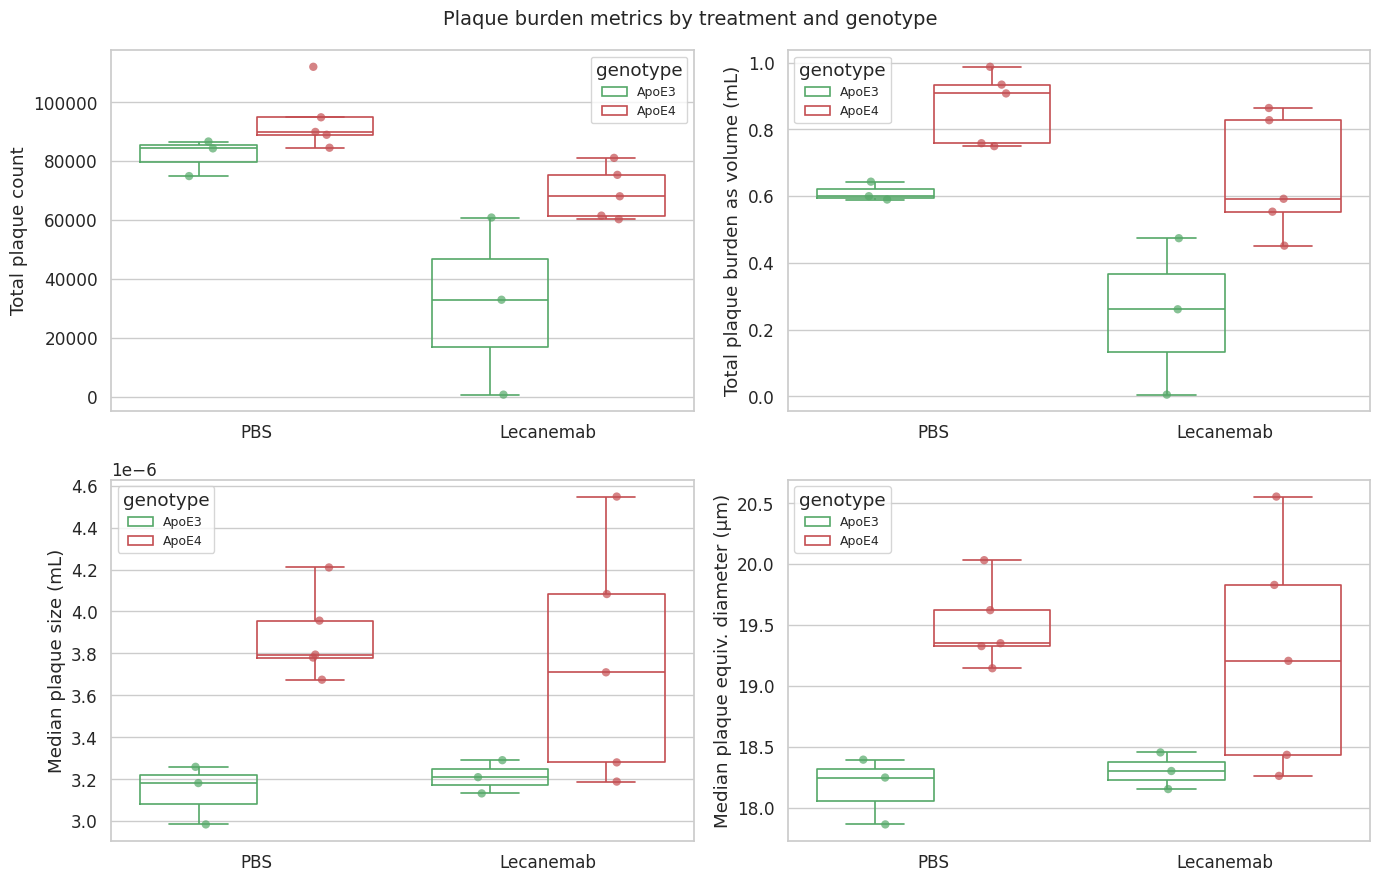

In [18]:
def boxstrip(ax, data, x, y, hue=None, order=None, hue_order=None, palette=None,
             ylabel=None, yscale="linear"):
    """Paired boxplot + stripplot helper."""
    sns.boxplot(data=data, x=x, y=y, hue=hue,
                order=order, hue_order=hue_order, palette=palette,
                fill=False, linewidth=1.2, fliersize=0, ax=ax)
    sns.stripplot(data=data, x=x, y=y, hue=hue,
                  order=order, hue_order=hue_order, palette=palette,
                  dodge=True, alpha=0.7, size=6, jitter=True, ax=ax)
    if yscale != "linear":
        ax.set_yscale(yscale)
    if ylabel:
        ax.set_ylabel(ylabel)
    # keep only one legend
    handles, labels = ax.get_legend_handles_labels()
    n = len(hue_order) if hue_order else 2
    ax.legend(handles[:n], labels[:n], title=hue, fontsize=9)


fig, axes = plt.subplots(2, 2, figsize=(14, 9))

metrics_to_plot = [
    ("plaque_count",   "Total plaque count",                "linear"),
    ("total_vol_ml",   "Total plaque burden as volume (mL)",    "linear"),
    ("median_vol_ml",  "Median plaque size (mL)",   "linear"),
    ("median_diam_um", "Median plaque equiv. diameter (µm)", "linear"),
]

for ax, (col, label, yscale) in zip(axes.flat, metrics_to_plot):
    boxstrip(ax, subj, x="treatment", y=col, hue="genotype",
             order=TREAT_ORDER, hue_order=GENO_ORDER, palette=GENO_PALETTE,
             ylabel=label, yscale=yscale)
    ax.set_xlabel("")

fig.suptitle("Plaque burden metrics by treatment and genotype", fontsize=14)
plt.tight_layout()
plt.savefig("fig_boxplots_treatment_genotype.png", dpi=150, bbox_inches="tight")
plt.show()

## 4  Violin plots of per-plaque size distributions

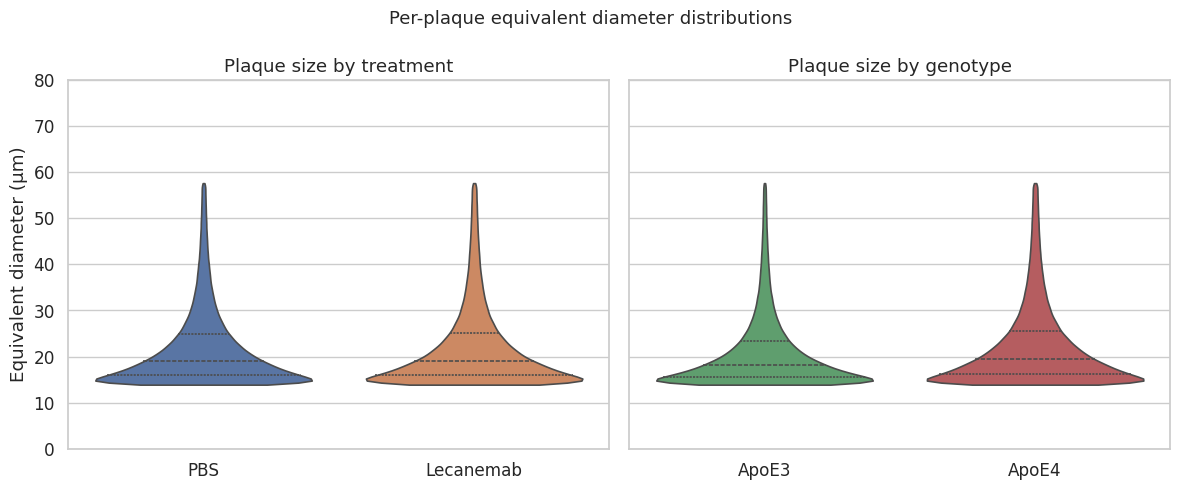

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (hue_col, hue_order, palette) in zip(
    axes,
    [
        ("treatment", TREAT_ORDER, TREAT_PALETTE),
        ("genotype",  GENO_ORDER,  GENO_PALETTE),
    ],
):
    sns.violinplot(
        data=df,
        x=hue_col,
        y="equiv_diam_um",
        order=hue_order,
        palette=palette,
        inner="quartile",
        cut=0,
        linewidth=1.2,
        ax=ax,
    )
    ax.set_ylabel("Equivalent diameter (µm)")
    ax.set_xlabel("")
    ax.set_ylim(0, 80)

axes[0].set_title("Plaque size by treatment")
axes[1].set_title("Plaque size by genotype")
fig.suptitle("Per-plaque equivalent diameter distributions", fontsize=13)
plt.tight_layout()
plt.savefig("fig_violin_plaque_size.png", dpi=150, bbox_inches="tight")
plt.show()

## 5  Two-way ANOVA: treatment × genotype

In [7]:
def run_twoway_anova(data, outcome, formula_extra=""):
    """
    Two-way OLS ANOVA: outcome ~ C(treatment) * C(genotype)
    Returns the type-II ANOVA table.
    """
    formula = f"{outcome} ~ C(treatment) * C(genotype)" + formula_extra
    model   = ols(formula, data=data).fit()
    table   = anova_lm(model, typ=2)
    return table


# outcomes to test (log-transformed for better normality)
outcomes = {
    "log_plaque_count":   "log(Plaque count)",
    "log_total_vol_ml":   "log(Total volume)",
    "log_mean_vol_ml":    "log(Mean volume)",
    "log_median_vol_ml":  "log(Median volume)",
    "mean_diam_um":       "Mean diameter (µm)",
    "median_diam_um":     "Median diameter (µm)",
}

anova_results = {}
summary_rows  = []

for col, label in outcomes.items():
    tbl = run_twoway_anova(subj, col)
    anova_results[col] = tbl
    for term, row in tbl.iterrows():
        summary_rows.append({
            "Outcome":  label,
            "Term":     term,
            "F":        row.get("F", np.nan),
            "p-value":  row.get("PR(>F)", np.nan),
        })

anova_summary = pd.DataFrame(summary_rows)
anova_summary["sig"] = anova_summary["p-value"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
)

print("Two-way ANOVA summary (type II SS)")
print("=" * 80)
print(anova_summary.to_string(index=False))

Two-way ANOVA summary (type II SS)
             Outcome                     Term         F  p-value sig
   log(Plaque count)             C(treatment)  3.615804 0.081509    
   log(Plaque count)              C(genotype)  3.644752 0.080443    
   log(Plaque count) C(treatment):C(genotype)  2.697428 0.126438    
   log(Plaque count)                 Residual       NaN      NaN    
   log(Total volume)             C(treatment)  3.304303 0.094135    
   log(Total volume)              C(genotype)  5.014378 0.044855   *
   log(Total volume) C(treatment):C(genotype)  2.491106 0.140475    
   log(Total volume)                 Residual       NaN      NaN    
    log(Mean volume)             C(treatment)  0.038320 0.848078    
    log(Mean volume)              C(genotype) 12.116532 0.004539  **
    log(Mean volume) C(treatment):C(genotype)  0.009139 0.925419    
    log(Mean volume)                 Residual       NaN      NaN    
  log(Median volume)             C(treatment)  0.121668 0.733276    

In [8]:
# ── pivot for a cleaner display ────────────────────────────────────────────────
pval_pivot = (
    anova_summary
    .pivot(index="Outcome", columns="Term", values="p-value")
    .rename(columns={
        "C(treatment)":                  "treatment",
        "C(genotype)":                   "genotype",
        "C(treatment):C(genotype)":      "treatment × genotype",
        "Residual":                      "Residual",
    })
)
print("\nANOVA p-values:")
pval_pivot.round(3).to_string()


ANOVA p-values:


'Term                  genotype  treatment  treatment × genotype  Residual\nOutcome                                                                  \nMean diameter (µm)       0.004      0.954                 0.762       NaN\nMedian diameter (µm)     0.003      0.749                 0.560       NaN\nlog(Mean volume)         0.005      0.848                 0.925       NaN\nlog(Median volume)       0.003      0.733                 0.535       NaN\nlog(Plaque count)        0.080      0.082                 0.126       NaN\nlog(Total volume)        0.045      0.094                 0.140       NaN'

## 6  Interaction plots

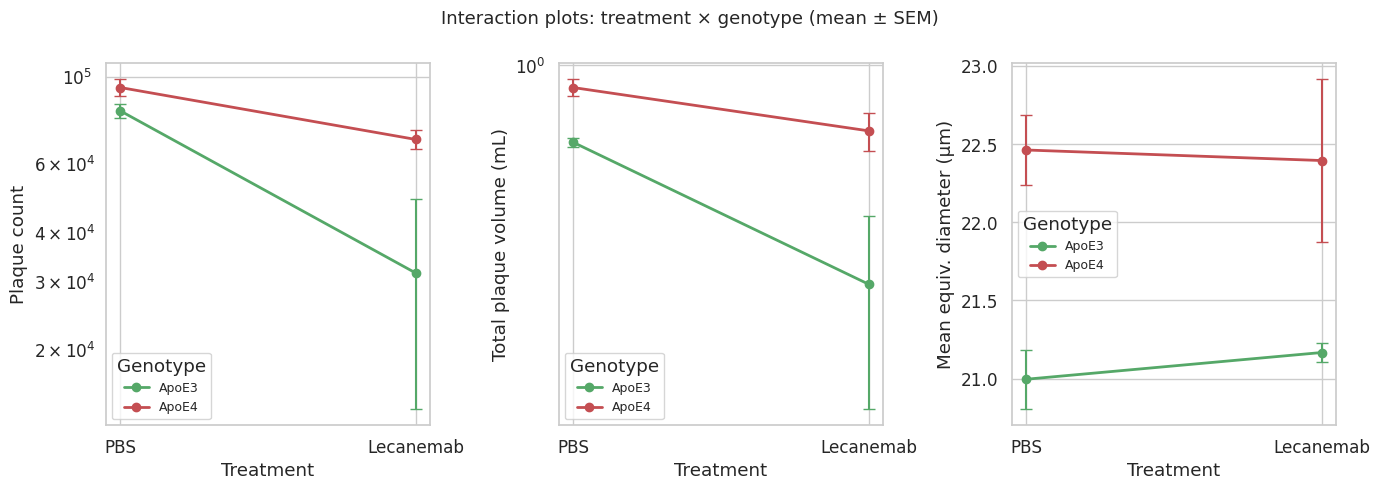

In [9]:
def interaction_plot_ax(ax, data, outcome, ylabel, yscale="linear"):
    """Mean ± SEM interaction plot (treatment on x, genotype as lines)."""
    agg = (
        data.groupby(["treatment", "genotype"], observed=True)[outcome]
        .agg(["mean", "sem"])
        .reset_index()
    )
    for geno, grp in agg.groupby("genotype", observed=True):
        color = GENO_PALETTE[geno]
        ax.plot(grp["treatment"].astype(str), grp["mean"],
                marker="o", linewidth=2, color=color, label=geno)
        ax.errorbar(grp["treatment"].astype(str), grp["mean"],
                    yerr=grp["sem"], fmt="none", color=color, capsize=4)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Treatment")
    if yscale != "linear":
        ax.set_yscale(yscale)
    ax.legend(title="Genotype", fontsize=9)


int_metrics = [
    ("plaque_count",  "Plaque count",              "log"),
    ("total_vol_ml",  "Total plaque volume (mL)",  "log"),
    ("mean_diam_um",  "Mean equiv. diameter (µm)", "linear"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (col, label, yscale) in zip(axes, int_metrics):
    interaction_plot_ax(ax, subj, col, label, yscale)

fig.suptitle("Interaction plots: treatment × genotype (mean ± SEM)", fontsize=13)
plt.tight_layout()
plt.savefig("fig_interaction_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## 7  Post-hoc pairwise comparisons (Tukey HSD)

In [10]:
def tukey_posthoc(data, outcome, group_col="treatment_genotype"):
    """Run Tukey HSD across all treatment × genotype combinations."""
    d = data.copy()
    d["group"] = d["treatment"].astype(str) + " | " + d["genotype"].astype(str)
    result = pairwise_tukeyhsd(d[outcome], d["group"], alpha=0.05)
    return result


posthoc_results = {}
for col, label in outcomes.items():
    res = tukey_posthoc(subj, col)
    posthoc_results[col] = res

print("Tukey HSD for log(Plaque count):")
print(posthoc_results["log_plaque_count"].summary())

Tukey HSD for log(Plaque count):
           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
      group1            group2      meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------
Lecanemab | ApoE3 Lecanemab | ApoE4   1.7937 0.1084 -0.3268 3.9142  False
Lecanemab | ApoE3       PBS | ApoE3   1.9667 0.1174 -0.4041 4.3376  False
Lecanemab | ApoE3       PBS | ApoE4   2.1014 0.0524 -0.0191  4.222  False
Lecanemab | ApoE4       PBS | ApoE3    0.173 0.9947 -1.9475 2.2936  False
Lecanemab | ApoE4       PBS | ApoE4   0.3078 0.9581 -1.5287 2.1442  False
      PBS | ApoE3       PBS | ApoE4   0.1347 0.9975 -1.9858 2.2552  False
-------------------------------------------------------------------------


In [11]:
print("Tukey HSD for log(Total volume):")
print(posthoc_results["log_total_vol_ml"].summary())

Tukey HSD for log(Total volume):
           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
      group1            group2      meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------
Lecanemab | ApoE3 Lecanemab | ApoE4   1.9927 0.0792 -0.1989 4.1844  False
Lecanemab | ApoE3       PBS | ApoE3   1.9486 0.1384 -0.5018 4.3989  False
Lecanemab | ApoE3       PBS | ApoE4   2.2936 0.0394  0.1019 4.4852   True
Lecanemab | ApoE4       PBS | ApoE3  -0.0442 0.9999 -2.2358 2.1475  False
Lecanemab | ApoE4       PBS | ApoE4   0.3008 0.9641 -1.5972 2.1989  False
      PBS | ApoE3       PBS | ApoE4    0.345 0.9648 -1.8466 2.5367  False
-------------------------------------------------------------------------


In [12]:
print("Tukey HSD for mean diameter (µm):")
print(posthoc_results["mean_diam_um"].summary())

Tukey HSD for mean diameter (µm):
           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
      group1            group2      meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------
Lecanemab | ApoE3 Lecanemab | ApoE4   1.2297 0.1625 -0.3858 2.8451  False
Lecanemab | ApoE3       PBS | ApoE3   -0.171 0.9918 -1.9772 1.6351  False
Lecanemab | ApoE3       PBS | ApoE4   1.2972 0.1334 -0.3183 2.9127  False
Lecanemab | ApoE4       PBS | ApoE3  -1.4007 0.0977 -3.0162 0.2147  False
Lecanemab | ApoE4       PBS | ApoE4   0.0675 0.9989 -1.3315 1.4665  False
      PBS | ApoE3       PBS | ApoE4   1.4682 0.0794 -0.1472 3.0837  False
-------------------------------------------------------------------------


In [13]:
# ── compact summary table ──────────────────────────────────────────────────────
def tukey_to_df(res, label):
    import numpy as np
    d = res.summary().data[1:]           # skip header row
    cols = res.summary().data[0]
    df_t = pd.DataFrame(d, columns=cols)
    df_t["outcome"] = label
    return df_t


frames = [tukey_to_df(posthoc_results[c], lbl) for c, lbl in outcomes.items()]
posthoc_df = pd.concat(frames, ignore_index=True)
posthoc_df["reject"] = posthoc_df["reject"].astype(str)

# show only significant contrasts
sig_contrasts = posthoc_df[posthoc_df["reject"] == "True"]
print(f"Significant Tukey contrasts: {len(sig_contrasts)}")
sig_contrasts[["outcome", "group1", "group2", "meandiff", "p-adj", "lower", "upper"]]

Significant Tukey contrasts: 3


,outcome,group1,group2,meandiff,p-adj,lower,upper
8,log(Total volume),Lecanemab | ApoE3,PBS | ApoE4,2.2936,0.0394,0.1019,4.4852
23,log(Median volume),PBS | ApoE3,PBS | ApoE4,0.2113,0.0404,0.0084,0.4142
35,Median diameter (µm),PBS | ApoE3,PBS | ApoE4,1.3269,0.0461,0.0207,2.6331


## 8  Genotype-stratified analysis

In [14]:
# ── within-genotype treatment comparisons (Mann-Whitney U) ────────────────────
strat_rows = []
for geno in GENO_ORDER:
    g = subj[subj["genotype"] == geno]
    pbs = g[g["treatment"] == "PBS"]
    lec = g[g["treatment"] == "Lecanemab"]

    for col, label in [
        ("plaque_count",  "Plaque count"),
        ("total_vol_ml",  "Total volume (mL)"),
        ("mean_diam_um",  "Mean diameter (µm)"),
    ]:
        stat, p = stats.mannwhitneyu(
            pbs[col].values, lec[col].values, alternative="two-sided"
        )
        # fold change (Lecanemab / PBS)
        fc = lec[col].median() / pbs[col].median()
        strat_rows.append(
            dict(genotype=geno, outcome=label,
                 PBS_median=pbs[col].median(), Lecanemab_median=lec[col].median(),
                 fold_change_LvP=fc, U=stat, p_value=p)
        )

strat_df = pd.DataFrame(strat_rows)
strat_df["sig"] = strat_df["p_value"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
)
print("Mann-Whitney U: PBS vs Lecanemab, stratified by genotype")
print(strat_df.to_string(index=False))

Mann-Whitney U: PBS vs Lecanemab, stratified by genotype
genotype            outcome   PBS_median  Lecanemab_median  fold_change_LvP    U  p_value  sig
   ApoE3       Plaque count 84353.000000      32964.000000         0.390786  9.0 0.100000 n.s.
   ApoE3  Total volume (mL)     0.599701          0.260973         0.435172  9.0 0.100000 n.s.
   ApoE3 Mean diameter (µm)    21.012751         21.222244         1.009970  3.0 0.700000 n.s.
   ApoE4       Plaque count 89948.000000      68095.000000         0.757049 25.0 0.007937   **
   ApoE4  Total volume (mL)     0.907562          0.591971         0.652264 21.0 0.095238 n.s.
   ApoE4 Mean diameter (µm)    22.223852         22.511562         1.012946 13.0 1.000000 n.s.


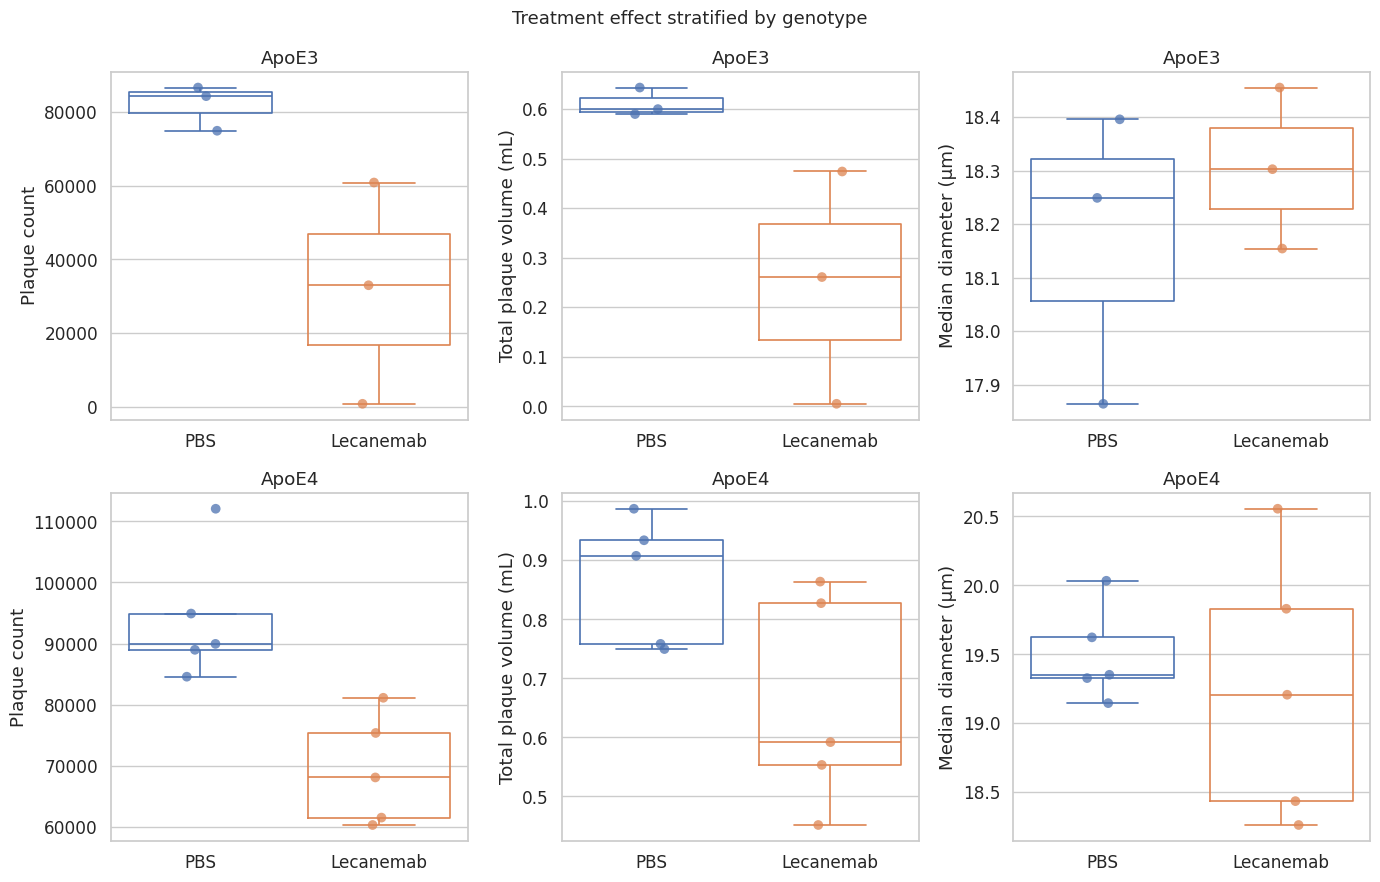

In [19]:
# ── boxplots faceted by genotype ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for geno, row_axes in zip(GENO_ORDER, axes):
    g = subj[subj["genotype"] == geno]
    for ax, (col, label, yscale) in zip(
        row_axes,
        [
            ("plaque_count",  "Plaque count",             "linear"),
            ("total_vol_ml",  "Total plaque volume (mL)", "linear"),
            ("median_diam_um",  "Median diameter (µm)",       "linear"),
        ],
    ):
        sns.boxplot(
            data=g, x="treatment", y=col,
            order=TREAT_ORDER, palette=TREAT_PALETTE,
            fill=False, linewidth=1.2, fliersize=0, ax=ax,
        )
        sns.stripplot(
            data=g, x="treatment", y=col,
            order=TREAT_ORDER, palette=TREAT_PALETTE,
            alpha=0.75, size=7, jitter=True, ax=ax,
        )
        if yscale != "linear":
            ax.set_yscale(yscale)
        ax.set_ylabel(label)
        ax.set_xlabel("")
        ax.set_title(geno)

fig.suptitle("Treatment effect stratified by genotype", fontsize=13)
plt.tight_layout()
plt.savefig("fig_stratified_by_genotype.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── ECDF of plaque size, faceted by treatment & genotype ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, geno in zip(axes, GENO_ORDER):
    g = df[df["genotype"] == geno]
    sns.ecdfplot(
        data=g,
        x="equiv_diam_um",
        hue="treatment",
        hue_order=TREAT_ORDER,
        palette=TREAT_PALETTE,
        ax=ax,
    )
    ax.set_xscale("log")
    ax.set_xlabel("Equivalent diameter (µm)")
    ax.set_ylabel("Cumulative fraction")
    ax.set_title(geno)

fig.suptitle("ECDF of plaque size by treatment, stratified by genotype", fontsize=13)
plt.tight_layout()
plt.savefig("fig_ecdf_size_by_genotype.png", dpi=150, bbox_inches="tight")
plt.show()

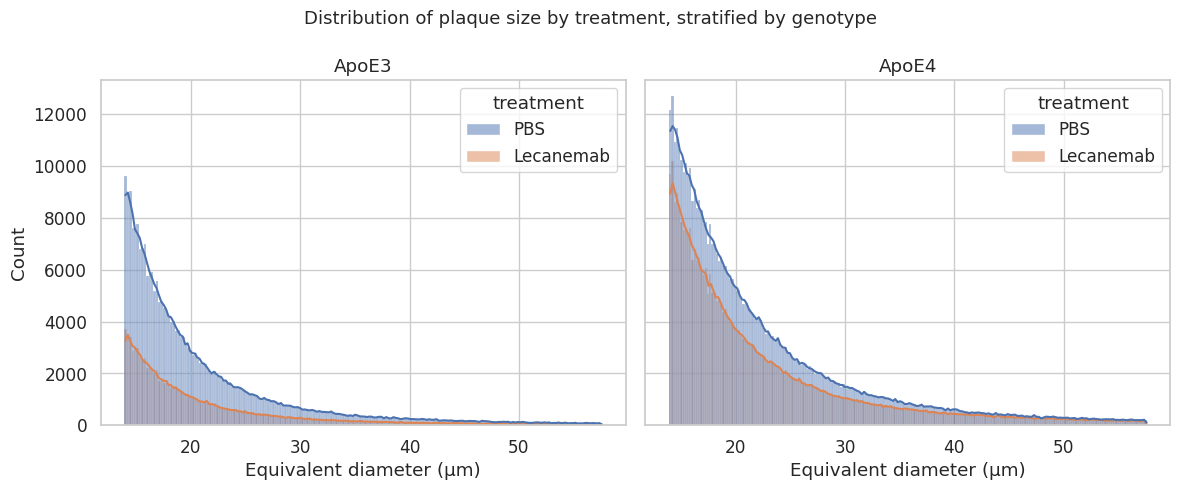

In [40]:
# ── Distribution plot of plaque size, faceted by treatment & genotype ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, geno in zip(axes, GENO_ORDER):
    g = df[df["genotype"] == geno]
    sns.histplot(
        data=g,
        x="equiv_diam_um",
        hue="treatment",
        kde=True,kde_kws={'clip':(14,100),'cut':0,'bw_adjust':0.1},
        hue_order=TREAT_ORDER,
        palette=TREAT_PALETTE,
        ax=ax,
    )
    ax.set_xscale("linear")
    ax.set_xlabel("Equivalent diameter (µm)")
    ax.set_ylabel("Count")
    ax.set_title(geno)

fig.suptitle("Distribution of plaque size by treatment, stratified by genotype", fontsize=13)
plt.tight_layout()
plt.savefig("fig_size_distribution_by_genotype.png", dpi=150, bbox_inches="tight")
plt.show()

## 9  Summary of findings

The cells below compile the ANOVA and stratified results into a concise narrative.

In [17]:
print("=" * 70)
print("SUMMARY OF FINDINGS")
print("=" * 70)

# ── group-level medians ──────────────────────────────────────────────────────
for key_metric, label in [("plaque_count", "Plaque count"),
                           ("total_vol_ml", "Total plaque volume (mL)")]:
    grp_med = (
        subj.groupby(["treatment", "genotype"], observed=True)[key_metric]
        .median()
        .reset_index()
        .pivot(index="genotype", columns="treatment", values=key_metric)
    )
    print(f"\nMedian {label}:")
    print(grp_med.to_string())

# ── ANOVA highlights ────────────────────────────────────────────────────────
print("\n" + "-" * 70)
print("Two-way ANOVA p-values:")
for col, label in outcomes.items():
    tbl = anova_results[col]
    p_treat = tbl.loc["C(treatment)", "PR(>F)"]
    p_geno  = tbl.loc["C(genotype)",  "PR(>F)"]
    p_inter = tbl.loc["C(treatment):C(genotype)", "PR(>F)"]
    def fmt_p(p):
        return f"p={p:.3f}" + (" *" if p < 0.05 else "")
    print(f"  {label:<30}  treatment: {fmt_p(p_treat)}  "
          f"genotype: {fmt_p(p_geno)}  interaction: {fmt_p(p_inter)}")

# ── stratified fold-changes ──────────────────────────────────────────────────
print("\n" + "-" * 70)
print("Median fold-change Lecanemab / PBS (stratified by genotype):")
fc_pivot = strat_df.pivot_table(
    index="outcome", columns="genotype", values="fold_change_LvP"
)
print(fc_pivot.to_string())

print("\n" + "=" * 70)
print("Notes for downstream vessel and regional analyses:")
print("  - Subject-level metrics table saved in variable: subj")
print("  - Per-plaque processed dataframe saved in variable: df")
print("  - ANOVA tables per outcome in dict: anova_results")
print("  - Tukey HSD results in dict: posthoc_results")
print("  - Stratified comparisons table: strat_df")
print("=" * 70)

SUMMARY OF FINDINGS

Median Plaque count:
treatment      PBS  Lecanemab
genotype                     
ApoE3      84353.0    32964.0
ApoE4      89948.0    68095.0

Median Total plaque volume (mL):
treatment       PBS  Lecanemab
genotype                      
ApoE3      0.599701   0.260973
ApoE4      0.907562   0.591971

----------------------------------------------------------------------
Two-way ANOVA p-values:
  log(Plaque count)               treatment: p=0.082  genotype: p=0.080  interaction: p=0.126
  log(Total volume)               treatment: p=0.094  genotype: p=0.045 *  interaction: p=0.140
  log(Mean volume)                treatment: p=0.848  genotype: p=0.005 *  interaction: p=0.925
  log(Median volume)              treatment: p=0.733  genotype: p=0.003 *  interaction: p=0.535
  Mean diameter (µm)              treatment: p=0.954  genotype: p=0.004 *  interaction: p=0.762
  Median diameter (µm)            treatment: p=0.749  genotype: p=0.003 *  interaction: p=0.560

---------